
# 1. Data Exploration
**Dataset Source:** [UCI Machine Learning Repository - Bank Marketing](https://www.kaggle.com/datasets/captaintyping/uci-bank-marketing-dataset/data)

### Introduction
This notebook documents the data preparation and feature engineering process for the Bank Marketing dataset.
The objective is to process the data so that a Logistic Regression model can be trained to predict
whether a client will subscribe to a term deposit (`yes` or `no`).


In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [12]:
df = pd.read_csv('bank-additional-full.csv', sep=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [13]:
(df == 'unknown').sum()

age                  0
job                330
marital             80
education         1731
default           8597
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64

## 1.1 Handling Missing Values

### Identification of Implicit Missing Values
Upon exploring the dataset, I identified that there are no "explicit" missing values (NaN or nulls). However, there are significant values represented by the string `"unknown"`. These appear in several categorical features, most notably in `job`, `education`, `housing`, and `loan`.

I am opting for Imputation using the Mode (the most frequent value) for categorical variables.

**Reasoning:**
1. **Preserving Data Volume:** Simply dropping all rows containing "unknown" would result in a significant loss of data (over 10% of the dataset), which could introduce bias and reduce the statistical power of the model.
2. **Feature Nature:** Since these features are categorical, the Mode is a statistically sound measure of central tendency to fill in gaps without introducing numerical outliers.

### Ordering and Data Leakage Prevention
I am performing the Train-Test Split *before* calculating the Mode for imputation. Calculating statistics (like the most frequent category) on the entire dataset would lead to Data Leakage, as information from the test set would "leak" into the training process. By splitting first, I ensure that the "unknown" values in the test set are filled based only on the patterns found in the training data.

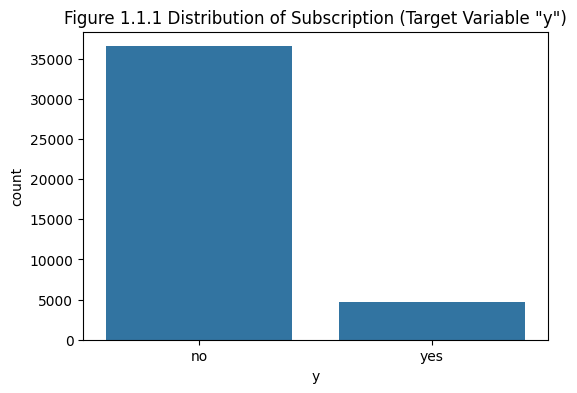

In [26]:
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title('Figure 1.1.1 Distribution of Subscription (Target Variable "y")')
plt.show()

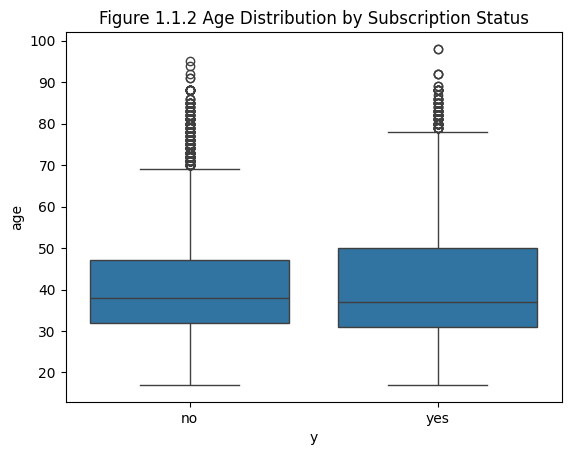

In [28]:
sns.boxplot(x='y', y='age', data = df)
plt.title('Figure 1.1.2 Age Distribution by Subscription Status')
plt.show()

## Observation for the Target Visualisation
Before preparing the data, a visualisation is useful to understand the underlying implications of the categorical variable.
For Figure 1.1.1, the plot reveals a major **class imbalance** in the target variable. Approximately 88% of the observations belong to the "no" class. Standard accuracy is a misleading metric for imbalanced datasets; therefore, I will need to address this later using SMOTE or an equivalent oversampling strategy. The Figure 1.1.2 reveals that the age distribution for both 'yes' and 'no' outcomes is similar, with medians centered at around 38 years. This indicates that age, on its own, may have low predictive power.

## 1.1.3 Bivariate Analysis
To move beyond, simple frequency counts, I am now analysing how the categorical features influence the subscription rate. This is a precursor to the Predictor Significance.

/var/folders/26/llfn3sts3hj0ymsnkhz5c4ch0000gn/T/ipykernel_4969/1985750924.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, palette='viridis', order=df[col].value_counts().index)
/var/folders/26/llfn3sts3hj0ymsnkhz5c4ch0000gn/T/ipykernel_4969/1985750924.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, palette='viridis', order=df[col].value_counts().index)
/var/folders/26/llfn3sts3hj0ymsnkhz5c4ch0000gn/T/ipykernel_4969/1985750924.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, pa

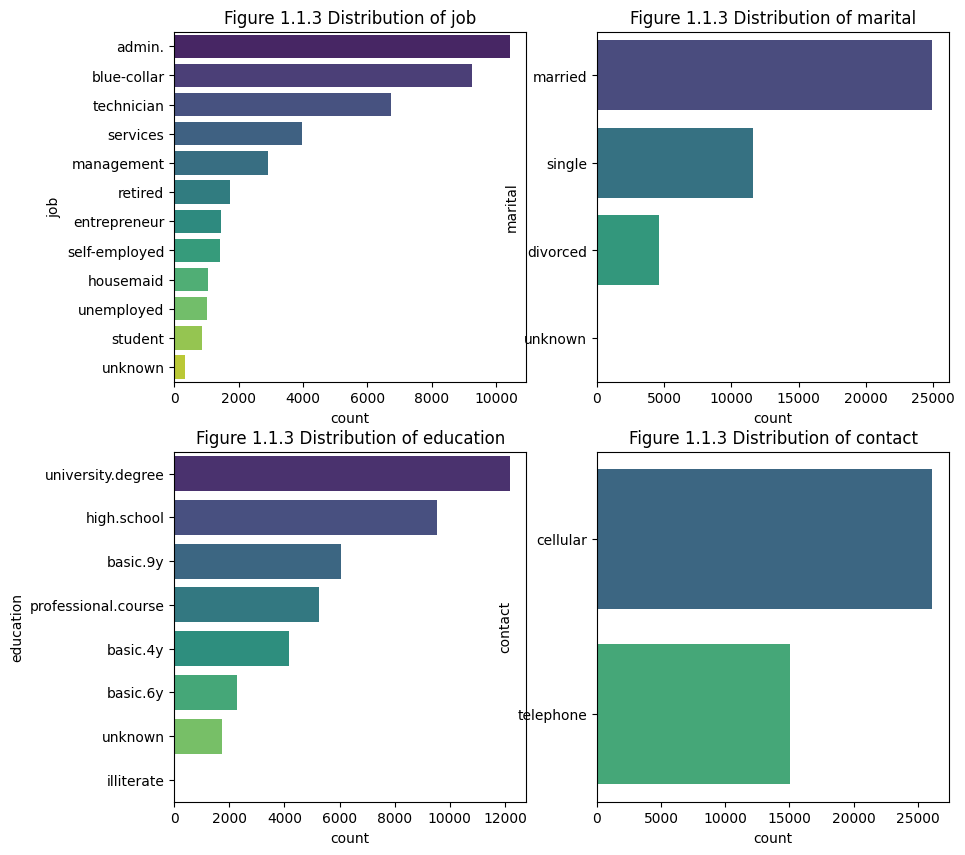

In [48]:
cat_cols = ['job', 'marital', 'education', 'contact']
plt.figure(figsize=(10, 10))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)
    sns.countplot(y=col, data=df, palette='viridis', order=df[col].value_counts().index)
    plt.title(f'Figure 1.1.3 Distribution of {col}')
plt.show()

## Predictor Visualisation (Feature Correlation)
This step is important to understand who is more likely to be subscribed.

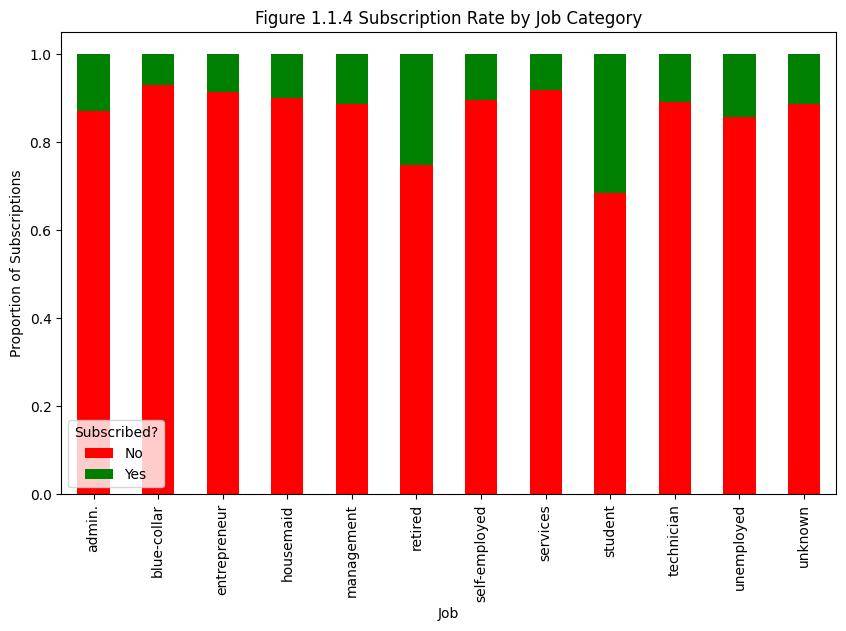

In [47]:
job_target = pd.crosstab(df['job'], df['y'])
job_target_pct = job_target.div(job_target.sum(1).astype(float), axis=0)

job_target_pct.plot(kind='bar', stacked=True, figsize=(10,6), color=['red', 'green'])
plt.title('Figure 1.1.4 Subscription Rate by Job Category')
plt.xlabel('Job')
plt.ylabel('Proportion of Subscriptions')
plt.legend(title='Subscribed?', labels=['No', 'Yes'])
plt.show()

The graph interesting shows that Retired individuals and students are likely to be subscribed!

## 1.2 Train-Test Split

### Objective
Before performing any data transformations, I am splitting the dataset into a **Training set (80%)** and a **Test set (20%)**.

If I were to calculate the "Mode" for missing values or the "Mean" for scaling using the entire dataset, information from the Test set would "leak" into the Training set. This would result in over-optimistic performance metrics that do not reflect how the model will perform on truly unseen data.

By splitting now, I ensure that all data preparation (imputation, encoding, and scaling) is learned strictly from the training data and then applied to the test data.


In [29]:
X = df.drop('y', axis=1)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"total rows in original data: {len(df)}")
print(f"rows in training set: {len(X_train)}")
print(f"rows in test set: {len(X_test)}")

total rows in original data: 41188
rows in training set: 32950
rows in test set: 8238


In [31]:
print((X_train == 'unknown').sum()) #running this cell again with the train set

age                  0
job                262
marital             61
education         1399
default           6857
housing            811
loan               811
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
dtype: int64


## 1.3 Managing Missing Values
After running another check for the implicit values, I have identified the following "unknown" categorical variables: `job`, `marital`, `education`, `default`, `housing` and `loan`. I will be moving forward with the "Mode" Imputation method because by using the most frequent value from the categorical variables, I maintain the nature of the dataset without losing rows. This is strictly performed using the `X_train` stat to avoid any data leakage.

In [36]:
cols_with_unknow = ['job', 'marital', 'education', 'default', 'housing', 'loan']

for col in cols_with_unknow:
    train_mod = X_train[X_train[col] != 'unknown'][col].mode()[0]
    X_train[col] = X_train[col].replace('unknown', train_mod)
    X_test[col] = X_test[col].replace('unknown', train_mod)
print("remaining unknown values in X_train:")
print((X_train == 'unknown').sum())

remaining unknown values in X_train:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
dtype: int64


I have included the `default` column in the imputation process. While 'unknown' could potentially be treated as its own category, the vast majority of the known entries are 'no'. Replacing 'unknown' with the mode ('no') prevents the model from over-complicating the feature space with a 'default_unknown' category, which, given the sparsity of 'yes' entries in this column, would likely add noise rather than predictive power.

In [37]:
y_train = y_train.map({'yes': 1, 'no': 0})
y_test = y_test.map({'yes': 1, 'no': 0})
print("First 5 values of y_train:")
print(y_train.head())

First 5 values of y_train:
12556    0
35451    0
30592    0
17914    0
3315     0
Name: y, dtype: int64


# 2. Preprocessing & Feature Engineering


In [55]:
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
X_train_encode = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encode = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)
X_train_encode, X_test_encoded = X_train_encode.align(X_test_encode, join='left', axis=1, fill_value=0)
print(f"Num of features after encoding: {X_train_encode.shape[1]}")
X_train_encode.head()

Num of features after encoding: 47


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
12556,40,94,2,999,0,1.4,93.918,-42.7,4.960,5228.1,...,False,False,False,False,True,False,False,False,True,False
35451,31,116,4,999,0,-1.8,92.893,-46.2,1.244,5099.1,...,True,False,False,False,True,False,False,False,True,False
30592,59,13,6,999,1,-1.8,92.893,-46.2,1.354,5099.1,...,True,False,False,False,True,False,False,False,False,False
17914,43,94,5,999,0,1.4,93.918,-42.7,4.961,5228.1,...,False,False,False,False,False,False,True,False,True,False
3315,39,344,2,999,0,1.1,93.994,-36.4,4.860,5191.0,...,True,False,False,False,False,True,False,False,True,False


## 2.1 Categorical Encoding
Since Logistic Regression is a distance-based and coefficient-based algorithm, it cannot interpret text. I am applying two types of encoding:

I applied **One-Hot Encoding:** to nominal variables like `job`, `marital`, and `contact`. This created binary "dummy" variables for each category, preventing the model from assuming a mathematical order where none exists (e.g., assuming 'married' is "greater" than 'single').
Further, I applied **Binary Mapping:** to `housing`, `loan`, and the target `y`. Since these are simple 'yes/no' questions, they are mapped to 1 and 0.

### Prevention of Data Leakage
I am following the rigorous practice of "fitting" my list of categories on the training set and "transforming" the test set to ensure consistent feature columns.

## 2.2 Numerical Feature Scaling

Standardization (StandardScaler) - Logistic Regression calculates coefficients based on feature magnitudes. Because our numerical features vary widely-for example: `age` (that is upto 98) versus `campaign` (number of contacts) - the model would naturally assign more weight to larger numbers.
I am using `StandardScaler` to transform the numerical data so that each feature has a mean of 0 and a standard deviation of 1. I'm using this because it is more robust to outliers which are present in `duration` and `campaign` columns and ensures that the model's gradient descent converges optimally.

In [67]:
num_cols = ['age', 'duration', 'campaign', 'pdays', 'previous',
            'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
            'euribor3m', 'nr.employed']
scaler = StandardScaler()
X_train_encode[num_cols] = scaler.fit_transform(X_train_encode[num_cols])
X_test_encoded[num_cols] = scaler.transform(X_test_encoded[num_cols])
print(" Mean of Scaled Features (Target: 0) -")
print(X_train_encode[num_cols].mean().round(2))
print(" Standard Deviation of Scaled Features (Target: 1) -")
print(X_train_encode[num_cols].std().round(2))

 Mean of Scaled Features (Target: 0) -
age               0.0
duration         -0.0
campaign          0.0
pdays            -0.0
previous          0.0
emp.var.rate     -0.0
cons.price.idx    0.0
cons.conf.idx     0.0
euribor3m        -0.0
nr.employed       0.0
dtype: float64
 Standard Deviation of Scaled Features (Target: 1) -
age               1.0
duration          1.0
campaign          1.0
pdays             1.0
previous          1.0
emp.var.rate      1.0
cons.price.idx    1.0
cons.conf.idx     1.0
euribor3m         1.0
nr.employed       1.0
dtype: float64


**According to the Medium article** [Multicollinearity Explained: When Features Collide and How to Fix It](https://medium.com/@sangeeth.pogula_25515/multicollinearity-explained-when-features-collide-and-how-to-fix-it-ab2c0cb116aa), if two variables are highly correlated the model gets confused about which one is actually causing the outcome. I will quickly check for high correlation among numerical features.


In [68]:
corr_matrix = X_train_encode[num_cols].corr()
high_corr = corr_matrix[corr_matrix > 0.8].stack().drop_duplicates()
print("highly correlated features (>0.8)")
print(high_corr)

highly correlated features (>0.8)
age           age            1.000000
emp.var.rate  euribor3m      0.972084
              nr.employed    0.906548
euribor3m     nr.employed    0.945144
dtype: float64


## 2.3 Feature Selection (Dropping Multicollinear Features)
Upon reviewing the correlation matrix, I have identified highly correlated matrixes. The are as follows: `euribor3m`, `emp.var.rate ` and `nr.employed`. I will only keep `euribor3m` as a representative indicator of economic context.

In [70]:
cols_drop = ['emp.var.rate', 'nr.employed']

# Drop from Training set
X_train_res_dropped = X_train_encode.drop(columns=cols_drop)

# Drop from Test set (important to keep them consistent!)
X_test_dropped = X_test_encoded.drop(columns=cols_drop)

print(f"features remaining: {X_train_res_dropped.shape[1]}")
print("dropped:", cols_drop)

features remaining: 45
dropped: ['emp.var.rate', 'nr.employed']
